# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("/content/data.csv")

# Display first 5 rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Check dataset shape
print("Dataset shape:", df.shape)

# Check column names
print("\nColumns:")
print(df.columns.tolist())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (41188, 21)

Columns:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Missing values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


## Customer Demographics Analysis

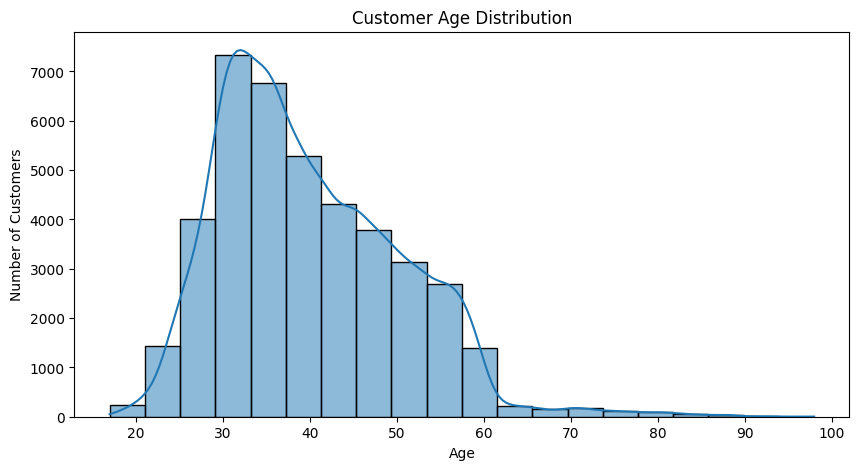

In [4]:

# Age distribution
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='age', bins=20, kde=True)

plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()


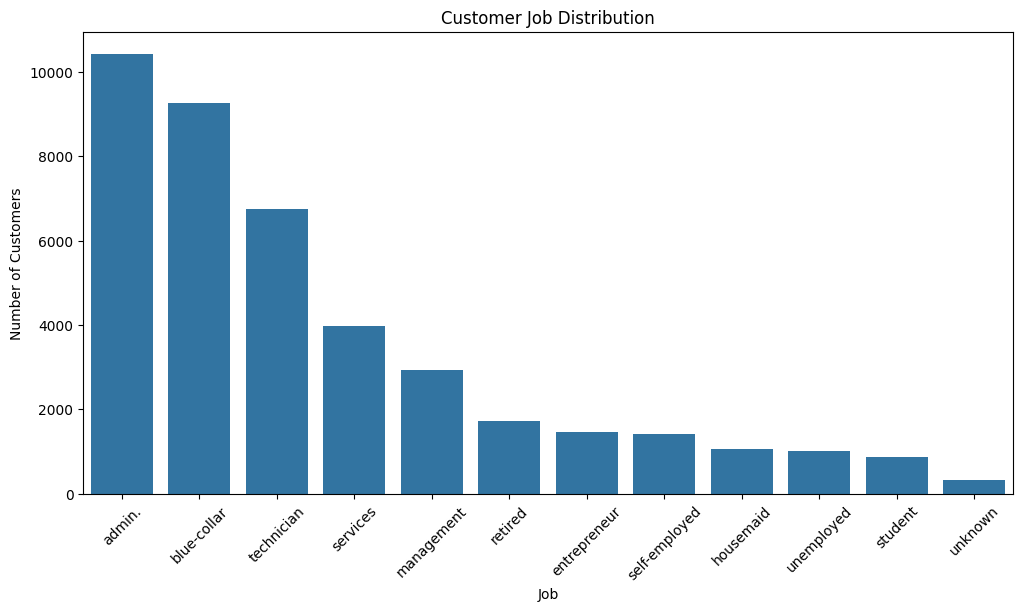

In [5]:
# Job distribution
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x='job', order=df['job'].value_counts().index)

plt.title('Customer Job Distribution')
plt.xlabel('Job')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

## Balance & Deposit Trends

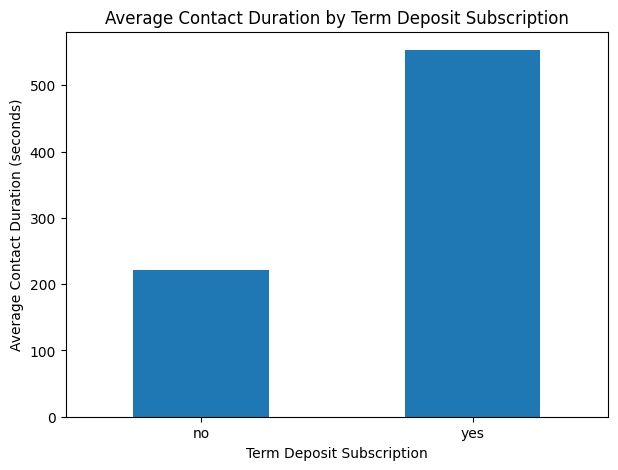

In [10]:
# Average contact duration by deposit subscription
avg_duration = df.groupby('y')['duration'].mean()

plt.figure(figsize=(7, 5))
avg_duration.plot(kind='bar')

plt.title('Average Contact Duration by Term Deposit Subscription')
plt.xlabel('Term Deposit Subscription')
plt.ylabel('Average Contact Duration (seconds)')
plt.xticks(rotation=0)
plt.show()

## Campaign Effectiveness

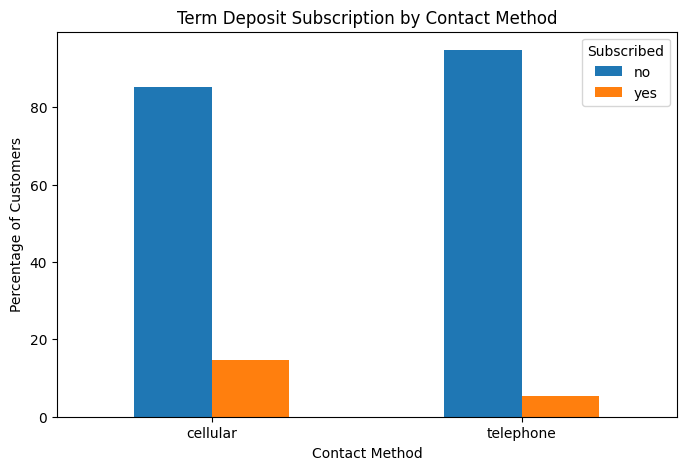

In [11]:
# Contact method analysis

contact_subscription = pd.crosstab(
    df['contact'],
    df['y'],
    normalize='index'
) * 100

contact_subscription.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Term Deposit Subscription by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Subscribed')
plt.show()


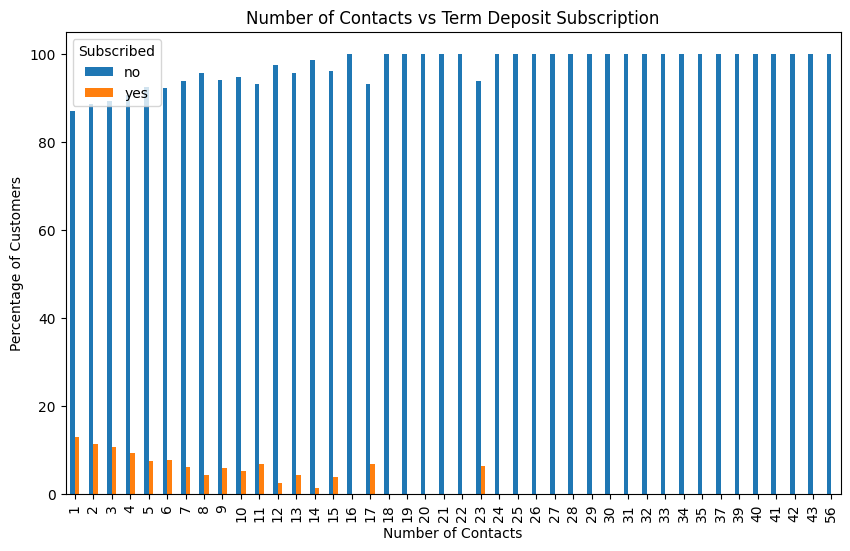

In [12]:
# Number of contacts vs deposit subscription

contact_analysis = pd.crosstab(
    df['campaign'],
    df['y'],
    normalize='index'
) * 100

contact_analysis.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Number of Contacts vs Term Deposit Subscription')
plt.xlabel('Number of Contacts')
plt.ylabel('Percentage of Customers')
plt.legend(title='Subscribed')
plt.show()


## Correlation Heatmap

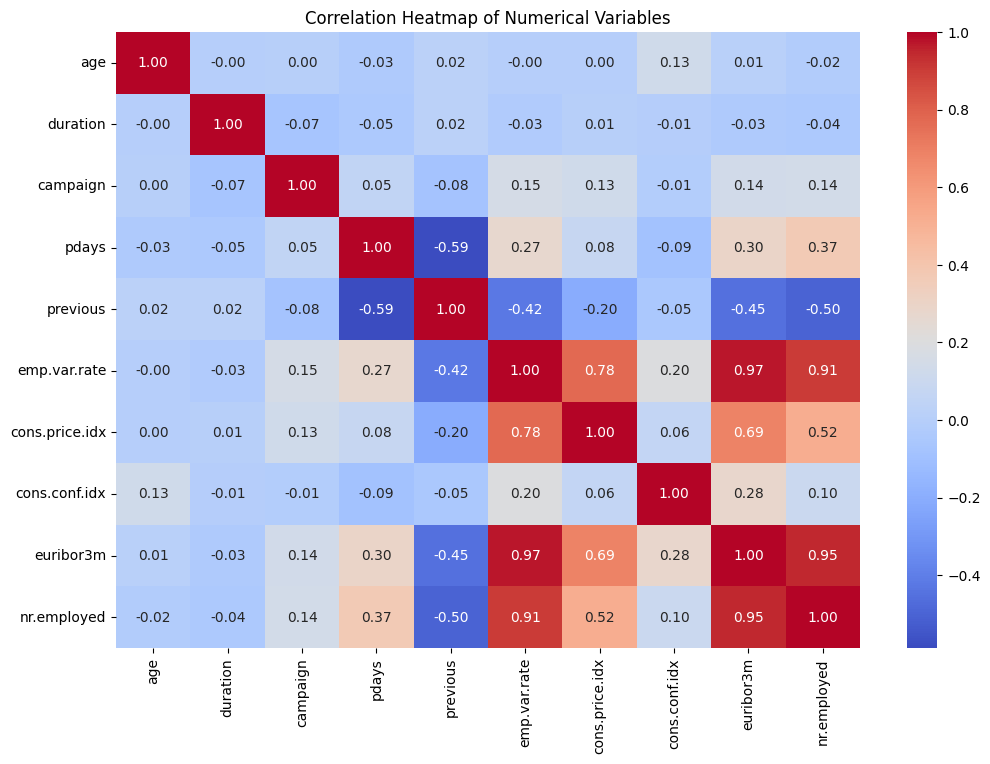

In [13]:
# Correlation of numerical variables
# Correlation of numerical variables

numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

## Predictive Modeling (Logistic Regression)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 91.43 %

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7310
           1       0.70      0.41      0.52       928

    accuracy                           0.91      8238
   macro avg       0.82      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238


Feature Importance:
           Feature  Coefficient  Importance
7          contact    -0.744833    0.744833
16  cons.price.idx     0.556009    0.556009
15    emp.var.rate    -0.518762    0.518762
4          default    -0.479771    0.479771
14        poutcome     0.407552    0.407552
13        previous    -0.243190    0.243190
18       euribor3m     0.232568    0.232568
2          marital     0.153769    0.153769
8            month    -0.088840    0.088840
3        education     0.052893    0.052893
9      day_of_week     0.051756    0.051756
11        campaign    -0.036454    0.036454
17   cons.conf.idx

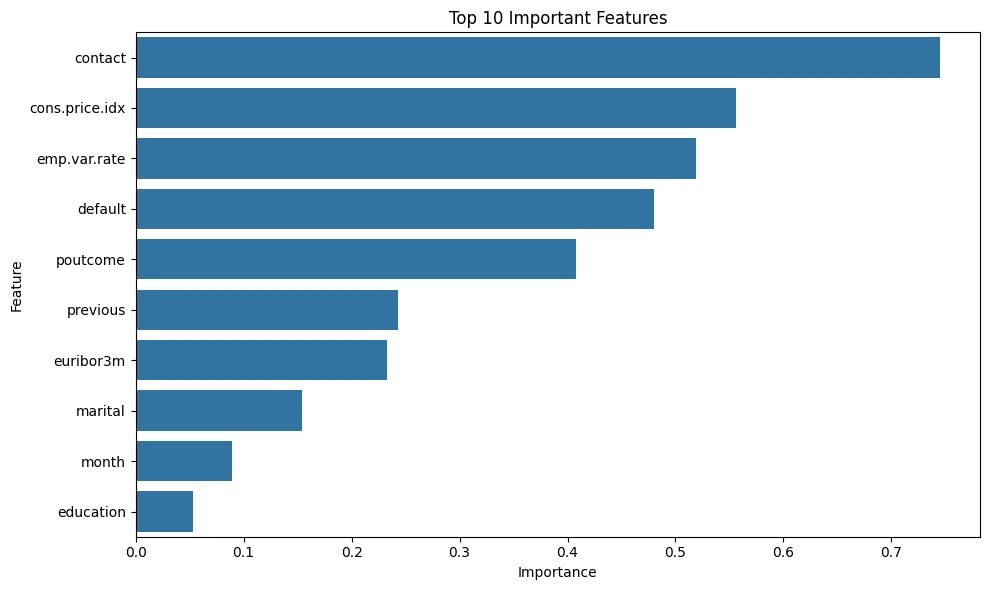

In [28]:
# ==========================================
# LOGISTIC REGRESSION + FEATURE IMPORTANCE
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Make a copy of the original dataset
df_model = df.copy()

# Encode all categorical columns
categorical_cols = df_model.select_dtypes(include='object').columns

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])

# Separate features and target
X = df_model.drop('y', axis=1)
y = df_model['y']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create and train Logistic Regression model
model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", round(accuracy * 100, 2), "%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Importance"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)

# ==========================================
# TOP 10 FEATURE IMPORTANCE GRAPH
# ==========================================

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.